# Pedestrians intention detection

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import os
from google.colab import drive
import pandas as pd
from tensorflow.keras.utils import plot_model

drive.mount('/content/drive')

Mounted at /content/drive


# Extract and Save the Frames

In [10]:
import cv2
import os

def save_video_frames_in_range(video_path, output_dir, start_frame=0, end_frame=500):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"[INFO] Total video frames: {total_frames}")
    print(f"[INFO] Extracting from frame {start_frame} to {end_frame}...")

    # Set the video reader to the starting frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    idx = start_frame
    saved = 0

    # Loop through the desired frame range
    while idx < end_frame:
        success, frame = cap.read()
        if not success:
            break
        # Save each frame as a JPEG file with a padded filename
        frame_filename = os.path.join(output_dir, f"frame_{idx:05d}.jpg")
        cv2.imwrite(frame_filename, frame)
        idx += 1
        saved += 1

    cap.release()
    print(f"[DONE] Saved {saved} frames to {output_dir}")

In [11]:
# Save the first 500 frames
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames", 0, 500)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 0 to 500...
[DONE] Saved 500 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [12]:
# Save the next 500 frames (from 500 to 1000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames", 500, 1000)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 500 to 1000...
[DONE] Saved 500 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [14]:
# Save the next 500 frames (from 1000 to 1500)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",1000,1500)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 1000 to 1500...
[DONE] Saved 500 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [15]:
# Save the next 500 frames (from 1500 to 2000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",1500,2000)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 1500 to 2000...
[DONE] Saved 500 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [16]:
# Save the next 500 frames (from 2000 to 2500)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",2000,2500)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 2000 to 2500...
[DONE] Saved 500 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [17]:
# Save the next 500 frames (from 2500 to 3000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",2500,3000)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 2500 to 3000...
[DONE] Saved 500 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [18]:
# Save the next 500 frames (from 3000 to 4000)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",3000,4000)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 3000 to 4000...
[DONE] Saved 1000 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [62]:
# Save the next 500 frames (from 4000 to 4507)
save_video_frames_in_range(VIDEO_PATH, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames",4000,4507)

[INFO] Total video frames: 4507
[INFO] Extracting from frame 4000 to 4507...
[DONE] Saved 507 frames to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames


In [63]:
XML_PATH = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/annotations-1.xml"
LABELS = {'Walking': 0, 'Standing': 1, 'Crossing': 2}

# 1. Parse annotations from XML
def parse_cvat_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    annotations = defaultdict(list)

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label not in LABELS:
            continue
        track_id = int(track.attrib["id"])
        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue
            annotations[track_id].append({
                "frame": frame,
                "bbox": [int(xtl), int(ytl), int(xbr), int(ybr)],
                "label": LABELS[label]
            })
    return annotations

# 2. Count total frames
def get_total_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"[INFO] Total frames: {total}")
    return total

# 3. Save all frames into a folder
def save_all_frames(video_path, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    cap = cv2.VideoCapture(video_path)
    idx = 0
    while True:
        success, frame = cap.read()
        if not success:
            break
        frame_name = f"frame_{idx:05d}.jpg"
        frame_path = os.path.join(output_dir, frame_name)
        cv2.imwrite(frame_path, frame)
        idx += 1
    cap.release()
    print(f"[INFO] Saved {idx} frames.")

def create_csv_with_labels(annotations, frames_folder, output_csv):
    rows = []
    for track_id, boxes in annotations.items():
        for box in boxes:
            frame_number = box['frame']
            label_id = box['label']
            label_name = [k for k, v in LABELS.items() if v == label_id][0]
            xtl, ytl, xbr, ybr = box['bbox']
            image_name = f"frame_{frame_number:05d}.jpg"
            rows.append([
                frame_number, image_name, label_name, label_id,
                xtl, ytl, xbr, ybr, track_id
            ])
    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'frame', 'image_name', 'label', 'label_id',
            'xtl', 'ytl', 'xbr', 'ybr', 'track_id'
        ])
        writer.writerows(rows)
    print(f"[INFO] CSV saved to {output_csv}")



In [64]:
import csv
FRAMES_FOLDER="/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames"
annotations = parse_cvat_xml(XML_PATH)
create_csv_with_labels(annotations, FRAMES_FOLDER, "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv")

[INFO] CSV saved to /content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv


In [78]:
df=pd.read_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv")

df.head()

,frame,image_name,label,label_id,xtl,ytl,xbr,ybr,track_id
0,0,frame_00000.jpg,Walking,0,963,574,1044,675,0
1,1,frame_00001.jpg,Walking,0,964,574,1045,675,0
2,2,frame_00002.jpg,Walking,0,965,574,1046,674,0
3,3,frame_00003.jpg,Walking,0,966,573,1047,674,0
4,4,frame_00004.jpg,Walking,0,967,573,1048,674,0


In [66]:
def extract_crossing_attributes(xml_path, frames_folder, label_filter='Crossing'):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    rows = []

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label != label_filter:
            continue
        track_id = int(track.attrib["id"])

        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue

            attr_dict = {
                "frame": frame,
                "image_path": os.path.join(frames_folder, f"frame_{frame:05d}.jpg"),
                "track_id": track_id,
                "xtl": xtl,
                "ytl": ytl,
                "xbr": xbr,
                "ybr": ybr,
                "label": label
            }

            # Add nested <attribute> tags
            for attr in box.findall("attribute"):
                attr_name = attr.attrib.get("name")
                attr_value = attr.text
                attr_dict[attr_name] = attr_value

            rows.append(attr_dict)

    return pd.DataFrame(rows)

# Run and save
print("[INFO] Extracting 'Crossing' attributes...")
df_crossing = extract_crossing_attributes(XML_PATH, FRAMES_FOLDER)
df_crossing.to_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/crossing_annotations.csv", index=False)
print("[DONE] Saved crossing_annotations.csv with", len(df_crossing), "rows.")


[INFO] Extracting 'Crossing' attributes...
[DONE] Saved crossing_annotations.csv with 1031 rows.


In [67]:
df_crossing=pd.read_csv("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/crossing_annotations.csv")

In [68]:
df_crossing.tail()

,frame,image_path,track_id,xtl,ytl,xbr,ybr,label,dressCodeStyle,location,fashionPersonality,judgmentCalls,age,weight,gender,disability,Distracted
1026,3156,/content/drive/MyDrive/Master/Autonmous Cars/W...,42,1244.40,424.58,1621.45,916.60,Crossing,Casual,notOnSidewalk,Minimalist,NoHandSignal,adult,NormalWeight,male,False,no
1027,3157,/content/drive/MyDrive/Master/Autonmous Cars/W...,42,1265.28,415.25,1659.23,929.05,Crossing,Casual,notOnSidewalk,Minimalist,NoHandSignal,adult,NormalWeight,male,False,no
1028,3158,/content/drive/MyDrive/Master/Autonmous Cars/W...,42,1286.17,405.92,1697.00,941.50,Crossing,Casual,notOnSidewalk,Minimalist,NoHandSignal,adult,NormalWeight,male,False,no
1029,3159,/content/drive/MyDrive/Master/Autonmous Cars/W...,42,1286.17,386.40,1721.90,941.50,Crossing,Casual,notOnSidewalk,Minimalist,NoHandSignal,adult,NormalWeight,male,False,no
1030,3160,/content/drive/MyDrive/Master/Autonmous Cars/W...,42,1433.69,388.18,1869.42,943.28,Crossing,Casual,notOnSidewalk,Minimalist,NoHandSignal,adult,NormalWeight,male,False,no


In [83]:
# Configs
CSV_PATH        = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/frames_labels.csv"
FRAMES_FOLDER   = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/Frames"
SEQUENCE_LENGTH = 10
IMAGE_SIZE      = (128, 128)

def preprocess_bbox(frame, bbox, size=IMAGE_SIZE):
    x1, y1, x2, y2 = bbox
    h, w, _ = frame.shape
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return cv2.resize(crop, size)

def generate_sequences_from_csv(csv_path, frames_folder, sequence_length=SEQUENCE_LENGTH):
    df = pd.read_csv(csv_path)
    # Build full path to each frame image
    df["image_path"] = df["image_name"].apply(lambda fn: os.path.join(frames_folder, fn))

    # Get the list of all image files in the frames folder
    existing_files = set(os.listdir(frames_folder))
    print("[DEBUG] Files found in frames folder:", len(existing_files))

    features, labels = [], []

    # Iterate over each pedestrian track
    for track_id, group in df.groupby("track_id"):
        group = group.sort_values("frame")
        records = group.to_dict(orient="records")

        # Skip if not enough frames
        if len(records) < sequence_length:
            continue

        # Sliding window over this track
        for start in range(len(records) - sequence_length + 1):
            seq_imgs = []
            for offset in range(sequence_length):
                rec = records[start + offset]
                frame_name = rec["image_name"]
                fp = os.path.join(frames_folder, frame_name)

                # Debug: Check if the frame file exists
                if frame_name not in existing_files:
                    print(f"[DEBUG] Missing frame: {fp}")
                    break

                img = cv2.imread(fp)
                if img is None:
                    print(f"[DEBUG] Failed to load frame: {fp}")
                    break

                crop = preprocess_bbox(img, [rec["xtl"], rec["ytl"], rec["xbr"], rec["ybr"]])
                if crop is None:
                    break
                seq_imgs.append(crop)

            if len(seq_imgs) == sequence_length:
                features.append(np.stack(seq_imgs, axis=0))
                labels.append(rec["label_id"])   # or rec["label"] if that's your numeric

    return np.array(features), np.array(labels)

# ——— Run everything ———
print("[INFO] Generating sequences from CSV…")
features, labels = generate_sequences_from_csv(CSV_PATH, FRAMES_FOLDER)

print("[INFO] Saving data…")
np.save("features.npy", features)
np.save("labels.npy", labels)

print(f"[DONE] Features shape: {features.shape}")
print(f"[DONE] Labels shape:   {labels.shape}")


[INFO] Generating sequences from CSV…
[DEBUG] Files found in frames folder: 4507
[INFO] Saving data…
[DONE] Features shape: (3374, 10, 128, 128, 3)
[DONE] Labels shape:   (3374,)


[INFO] Showing sequence 0 | Label: Walking


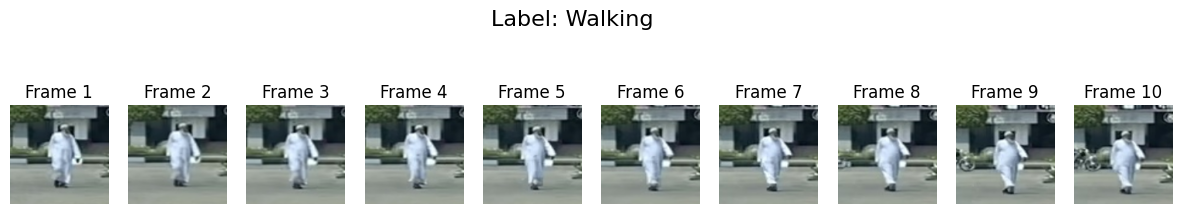

[INFO] Showing sequence 1 | Label: Walking


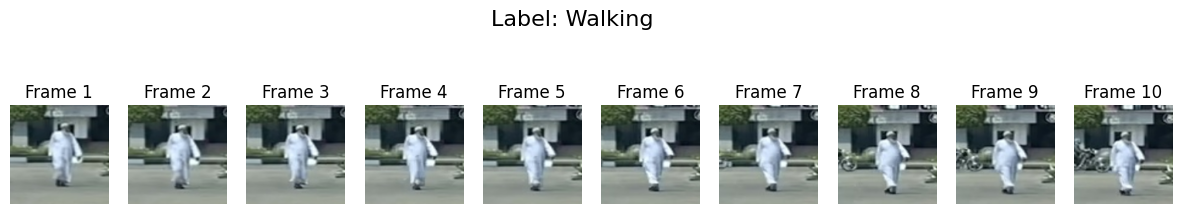

[INFO] Showing sequence 2 | Label: Walking


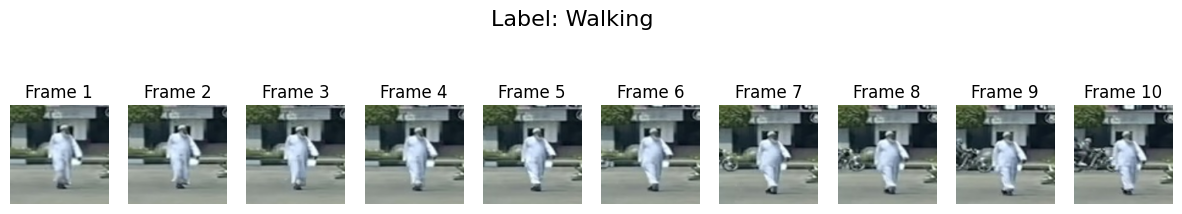

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved features and labels
features = np.load("features.npy")
labels = np.load("labels.npy")

# Reverse label map
LABELS_INV = {0: 'Walking', 1: 'Standing', 2: 'Crossing'}

# Visualize sequence using matplotlib
def visualize_sequence_matplotlib(sequence, label):
    plt.figure(figsize=(15, 3))
    for i, frame in enumerate(sequence):
        plt.subplot(1, len(sequence), i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Frame {i+1}")
    plt.suptitle(f"Label: {LABELS_INV[label]}", fontsize=16)
    plt.show()

# Show the first 3 sequences
for i in range(3):
    print(f"[INFO] Showing sequence {i} | Label: {LABELS_INV[labels[i]]}")
    visualize_sequence_matplotlib(features[i], labels[i])


# Load the Cvat Data

In [3]:
!pip install tqdm

In [4]:
%%capture
import os
import cv2
# import pafy
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model





  if event.key is 'enter':



In [5]:
import cv2
import os
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict
from tqdm import tqdm

# CONFIG
VIDEO_PATH = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/v1.mov"
XML_PATH = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/annotations-1.xml"
SEQUENCE_LENGTH = 10  # <- reduced from 5
IMAGE_SIZE = (128, 128)  # <- reduced from (64, 64)
LABELS = {'Walking': 0, 'Standing': 1, 'Crossing': 2}
MAX_FRAMES = 500  # <- limit to avoid memory issues
MAX_TRACKS = 5    # <- limit number of tracks for testing

# 1. Parse XML annotations
def parse_cvat_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    annotations = defaultdict(list)

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label not in LABELS:
            continue

        track_id = int(track.attrib["id"])
        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue
            annotations[track_id].append({
                "frame": frame,
                "bbox": [int(xtl), int(ytl), int(xbr), int(ybr)],
                "label": LABELS[label]
            })
    return annotations

# 2. Load limited video frames
def load_video_frames(video_path, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(video_path)
    frame_map = {}
    idx = 0
    success, frame = cap.read()
    while success and idx < max_frames:
        frame_map[idx] = frame
        idx += 1
        success, frame = cap.read()
    cap.release()
    return frame_map

# 3. Crop & resize bbox region
def preprocess_bbox(frame, bbox, size=IMAGE_SIZE):
    x1, y1, x2, y2 = bbox
    h, w, _ = frame.shape
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    crop = cv2.resize(crop, size)
    return crop

# 4. Generate sequences
def generate_sequences(annotations, frame_map, sequence_length=SEQUENCE_LENGTH):
    features, labels = [], []

    for track_id, boxes in list(annotations.items())[:MAX_TRACKS]:  # Limit tracks
        boxes = sorted(boxes, key=lambda x: x["frame"])
        if len(boxes) < sequence_length:
            continue

        for i in range(0, len(boxes) - sequence_length + 1):
            sequence = []
            for j in range(sequence_length):
                box_info = boxes[i + j]
                frame = frame_map.get(box_info["frame"])
                if frame is None:
                    break
                processed = preprocess_bbox(frame, box_info["bbox"])
                if processed is None:
                    break
                sequence.append(processed)
            if len(sequence) == sequence_length:
                features.append(np.array(sequence))
                labels.append(box_info["label"])

    return np.array(features), np.array(labels)

# 5. Run everything
print("[INFO] Parsing annotations...")
annotations = parse_cvat_xml(XML_PATH)

print("[INFO] Loading video frames (max:", MAX_FRAMES, ")...")
frame_map = load_video_frames(VIDEO_PATH, MAX_FRAMES)
print(f"[INFO] Loaded {len(frame_map)} frames.")

print("[INFO] Generating sequences...")
features, labels = generate_sequences(annotations, frame_map)

print("[INFO] Saving data...")
np.save("features.npy", features)
np.save("labels.npy", labels)

print("[DONE] Features shape:", features.shape)
print("[DONE] Labels shape:", labels.shape)


[INFO] Parsing annotations...
[INFO] Loading video frames (max: 500 )...
[INFO] Loaded 500 frames.
[INFO] Generating sequences...
[INFO] Saving data...
[DONE] Features shape: (952, 10, 128, 128, 3)
[DONE] Labels shape: (952,)


In [6]:
import pandas as pd

def extract_crossing_attributes(xml_path, label_filter='Crossing'):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    rows = []

    for track in root.findall("track"):
        label = track.attrib["label"]
        if label != label_filter:
            continue
        track_id = int(track.attrib["id"])

        for box in track.findall("box"):
            frame = int(box.attrib["frame"])
            xtl = float(box.attrib["xtl"])
            ytl = float(box.attrib["ytl"])
            xbr = float(box.attrib["xbr"])
            ybr = float(box.attrib["ybr"])
            outside = int(box.attrib["outside"])
            if outside == 1:
                continue

            attr_dict = { "frame": frame, "track_id": track_id, "xtl": xtl, "ytl": ytl, "xbr": xbr, "ybr": ybr }

            # Add box attributes
            for k, v in box.attrib.items():
                if k not in attr_dict:
                    attr_dict[k] = v

            # Add nested <attribute> tags inside <box>
            for attr in box.findall("attribute"):
                attr_name = attr.attrib.get("name")
                attr_value = attr.text
                attr_dict[attr_name] = attr_value

            rows.append(attr_dict)

    return pd.DataFrame(rows)

# Extract and save
print("[INFO] Extracting Crossing attributes...")
df_crossing = extract_crossing_attributes(XML_PATH)
df_crossing.to_csv("crossing_annotations.csv", index=False)
print("[DONE] Saved crossing_annotations.csv with", len(df_crossing), "rows.")


[INFO] Extracting Crossing attributes...
[DONE] Saved crossing_annotations.csv with 1031 rows.


In [8]:
df_crossing.head()

,frame,track_id,xtl,ytl,xbr,ybr,keyframe,outside,occluded,z_order,dressCodeStyle,location,fashionPersonality,judgmentCalls,age,weight,gender,disability,Distracted
0,322,6,1137.60,555.8,1190.04,647.65,1,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
1,323,6,1138.71,555.8,1191.15,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
2,324,6,1139.82,555.8,1192.26,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
3,325,6,1140.92,555.8,1193.36,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no
4,326,6,1142.03,555.8,1194.47,647.65,0,0,0,0,Casual,notOnSidewalk,Minimalist,HandSignal,Senior,NormalWeight,male,false,no


[INFO] Showing sequence 0 | Label: Walking


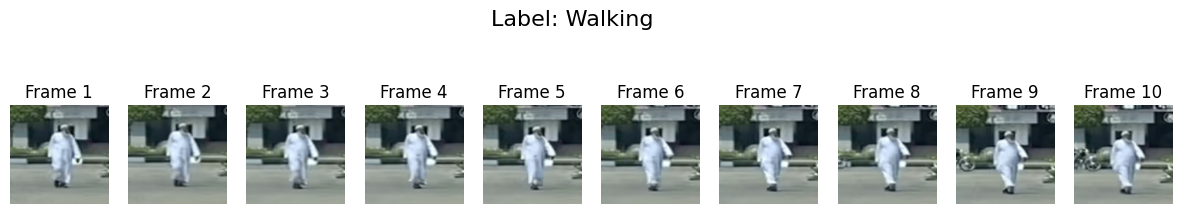

[INFO] Showing sequence 1 | Label: Walking


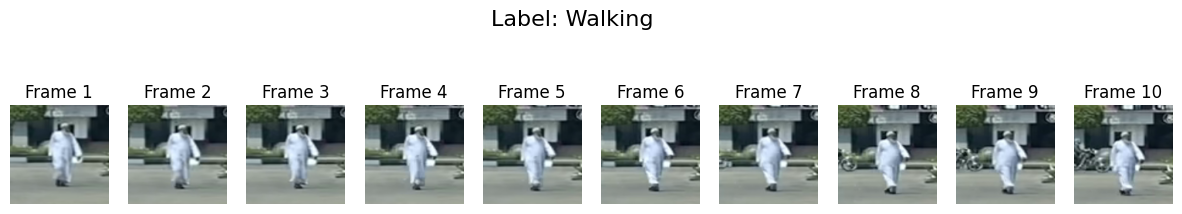

[INFO] Showing sequence 2 | Label: Walking


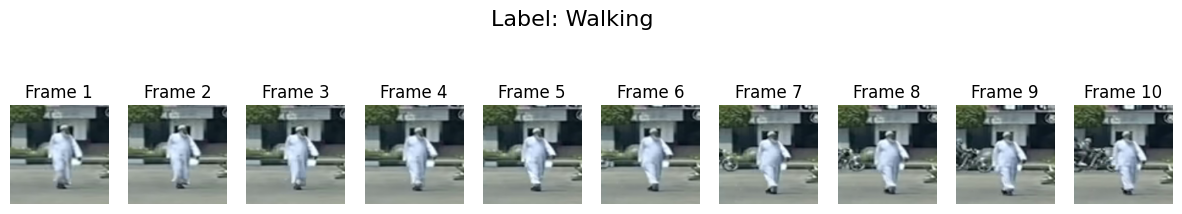

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved features and labels
features = np.load("features.npy")
labels = np.load("labels.npy")

# Reverse label map
LABELS_INV = {0: 'Walking', 1: 'Standing', 2: 'Crossing'}

# Visualize sequence using matplotlib
def visualize_sequence_matplotlib(sequence, label):
    plt.figure(figsize=(15, 3))
    for i, frame in enumerate(sequence):
        plt.subplot(1, len(sequence), i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Frame {i+1}")
    plt.suptitle(f"Label: {LABELS_INV[label]}", fontsize=16)
    plt.show()

# Show the first 3 sequences
for i in range(3):
    print(f"[INFO] Showing sequence {i} | Label: {LABELS_INV[labels[i]]}")
    visualize_sequence_matplotlib(features[i], labels[i])


# Train  BI LRCN
TimeDistributed CNN + Bi-LSTM (i.e., an LRCN model with a bidirectional LSTM), which is a great choice for spatiotemporal data like video frames or sequential image data.



In [86]:
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.layers import Conv2D, TimeDistributed
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Constants
SEQUENCE_LENGTH = 10  # or any desired sequence length
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128

# Update to 3 output classes instead of
CLASSES_LIST = {
    0: 'walking',
    1: 'standing',
    2: 'crossing'
}

def create_LRCN_model():
    '''
    This function will construct the required LRCN model with Bi-LSTM.
    Returns:
        model: The constructed LRCN model.
    '''

    # We will use a Sequential model for model construction.
    model = Sequential()

    # Define the Model Architecture.
    ########################################################################################################################

    # TimeDistributed wrapper for 2D Convolution
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'),
                              input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    # Flatten the convolutional output
    model.add(TimeDistributed(Flatten()))

    # Use Bi-LSTM instead of LSTM
    model.add(Bidirectional(LSTM(32)))  # Bidirectional LSTM for sequence learning

    # Final output layer (softmax for classification with 3 output classes)
    model.add(Dense(3, activation='softmax'))  # Updated to 3 output classes

    ########################################################################################################################

    # Display the models summary.
    model.summary()

    # Return the constructed LRCN model.
    return model


In [ ]:
# Construct the required LRCN model.
LRCN_model = create_LRCN_model() # Display the success message. print("Model Created Successfully!")

  super().__init__(**kwargs)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 128, 128,   │           448 │
│ (TimeDistributed)               │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 32, 32, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 8, 8, 32)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 8, 8, 64)   │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 4, 4, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 4, 4, 64)   │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 2, 2, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 256)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,691 (526.14 KB)

 Trainable params: 134,691 (526.14 KB)

 Non-trainable params: 0 (0.00 B)

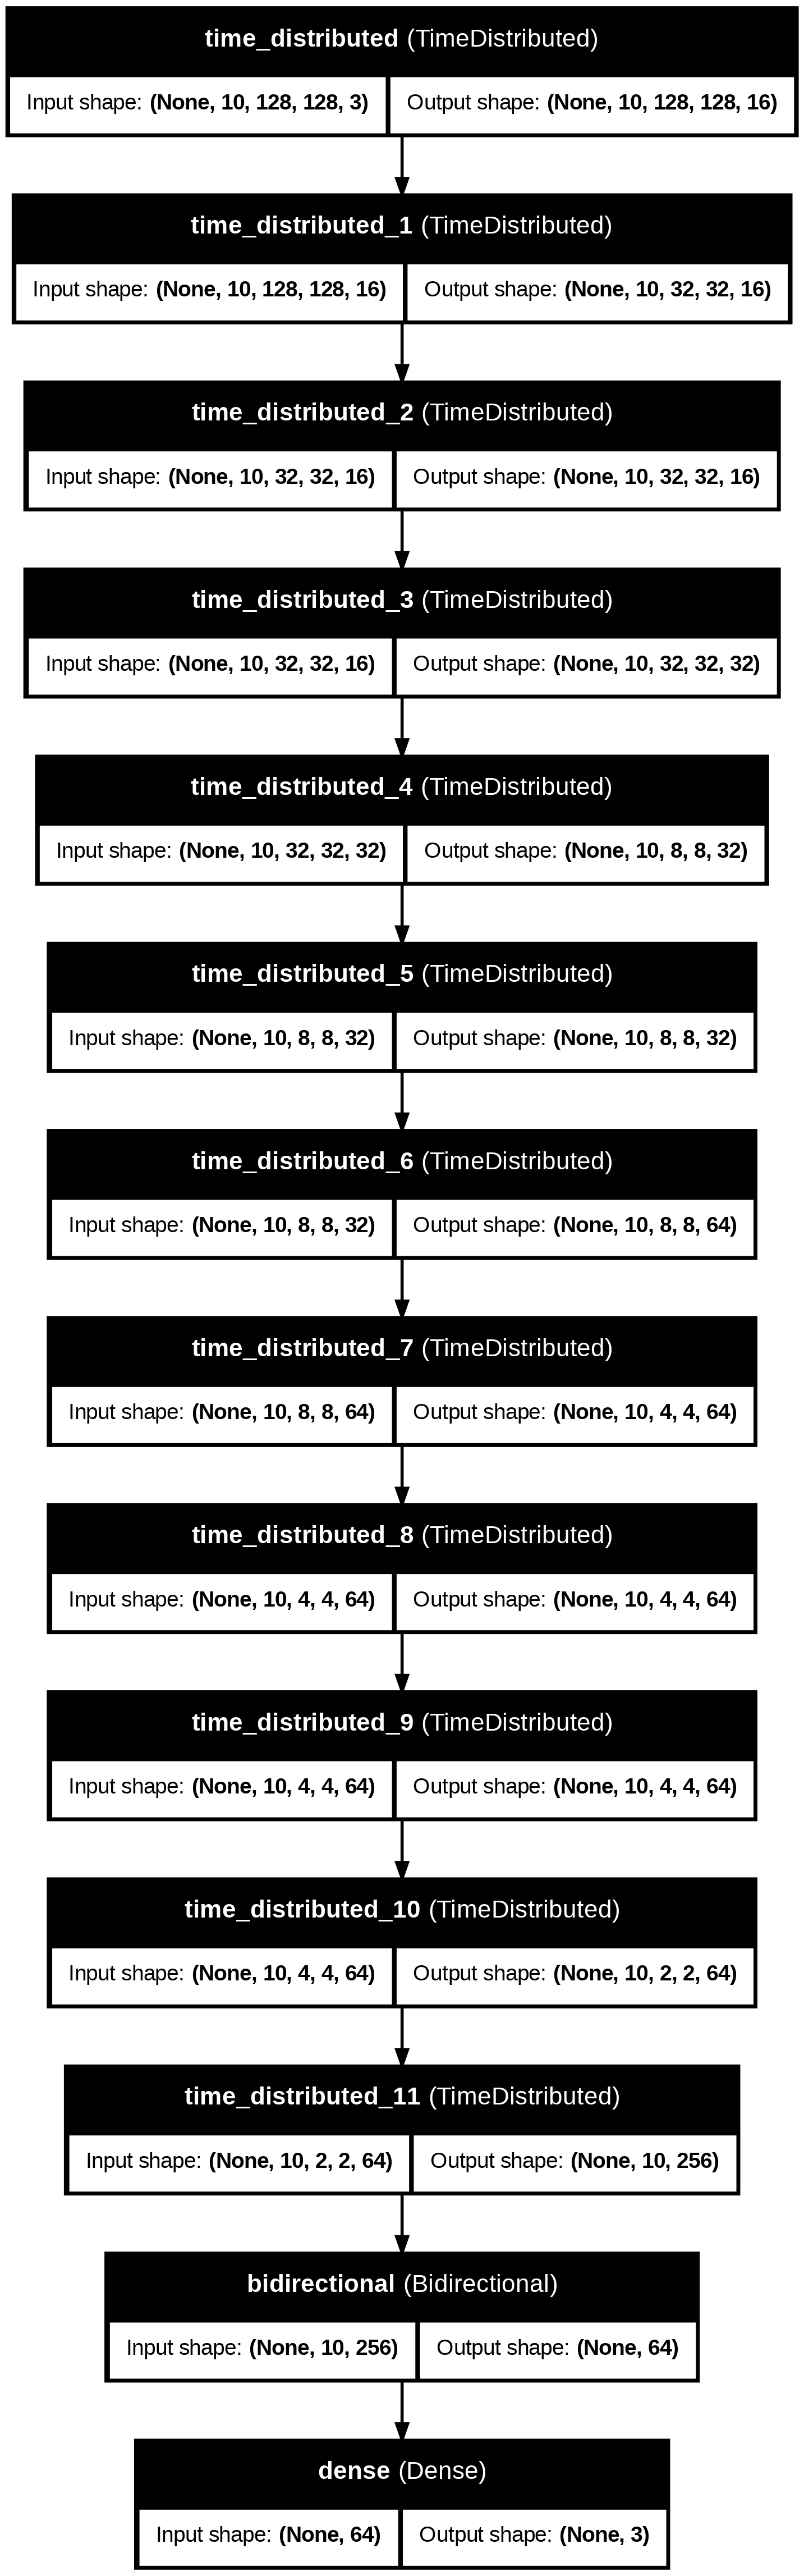

In [ ]:
# Plot the structure of the contructed LRCN model.
plot_model(LRCN_model, to_file = 'LRCN_model_structure_plot.png', show_shapes = True, show_layer_names = True)

In [ ]:
from tensorflow.keras.utils import to_categorical

# Define the class list based on the LABELS dict
classes_list = ['Walking', 'Standing', 'Crossing']  # Order must match LABELS dictionary

# Normalize the feature values to range [0, 1]
features = features.astype('float32') / 255.0

# One-hot encode the labels
labels = to_categorical(labels, num_classes=len(classes_list))

# Final shapes check
print(f"Features shape: {features.shape}")  # (num_samples, SEQUENCE_LENGTH, H, W, C)
print(f"Labels shape (one-hot): {labels.shape}")  # (num_samples, num_classes)


Features shape: (952, 10, 128, 128, 3)
Labels shape (one-hot): (952, 3)


In [ ]:
# # Create an Instance of Early Stopping Callback.
# early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# # Compile the model and specify loss function, optimizer and metrics to the model.
# LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# # Start training the model.
# LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 300, batch_size = 32 , shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])



In [ ]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',
    restore_best_weights=True
)

# Compile model
LRCN_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the model
LRCN_model_training_history = LRCN_model.fit(
    x=features_train,
    y=labels_train,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    verbose=1
)


Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 178s 9s/step - accuracy: 0.6225 - loss: 0.7082 - val_accuracy: 0.6732 - val_loss: 0.7851
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 159s 8s/step - accuracy: 0.7986 - loss: 0.4227 - val_accuracy: 0.6732 - val_loss: 0.7878
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 212s 9s/step - accuracy: 0.8637 - loss: 0.3096 - val_accuracy: 0.6732 - val_loss: 1.0528
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 168s 9s/step - accuracy: 0.9729 - loss: 0.1775 - val_accuracy: 0.6732 - val_loss: 1.3150
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 204s 9s/step - accuracy: 0.9989 - loss: 0.0805 - val_accuracy: 0.6732 - val_loss: 1.1445
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 191s 8s/step - accuracy: 1.0000 - loss: 0.0609 - val_accuracy: 0.6732 - val_loss: 1.8199
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 202s 8s/step - accuracy: 0.9953 - loss: 0.0421 - val_accuracy: 0.6732 - val_loss: 1.9983
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 201s 8s/step - accuracy: 0.9952 - loss: 0.0337 - val_accuracy: 0.6732 - v

In [ ]:
# Now evaluate the model
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

# Print evaluation results
print(f"Evaluation results: {model_evaluation_history}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7585 - loss: 0.6048
Evaluation results: [0.6259127855300903, 0.7486910820007324]


In [ ]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

# Save the Model.
LRCN_model.save(model_file_name)

In [ ]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    '''
    This function will plot the metrics passed to it in a graph.
    Args:
        model_training_history: A history object containing a record of training and validation
                                loss values and metrics values at successive epochs
        metric_name_1:          The name of the first metric that needs to be plotted in the graph.
        metric_name_2:          The name of the second metric that needs to be plotted in the graph.
        plot_name:              The title of the graph.
    '''

    # Get metric values using metric names as identifiers.
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Construct a range object which will be used as x-axis (horizontal plane) of the graph.
    epochs = range(len(metric_value_1))

    # Plot the Graph.
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

    # Add title to the plot.
    plt.title(str(plot_name))

    # Add legend to the plot.
    plt.legend()

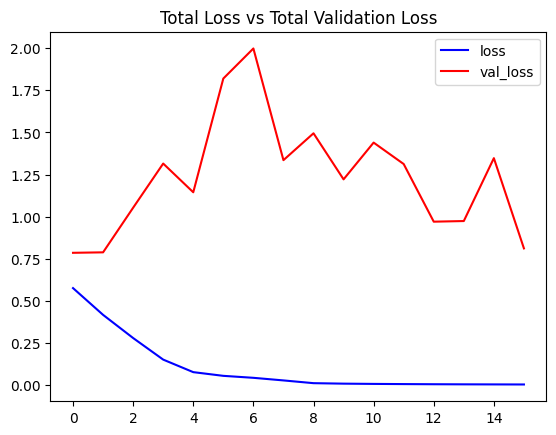

In [ ]:
# Visualize the training and validation loss metrices.
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

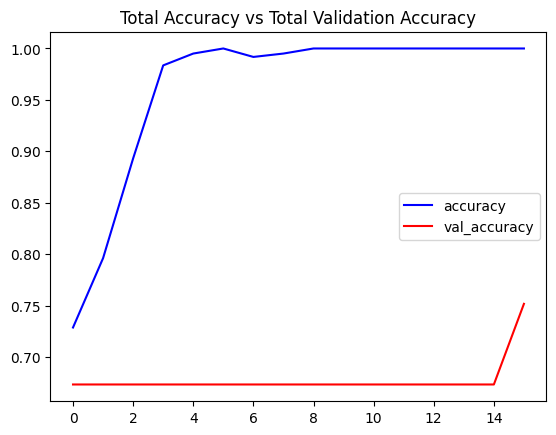

In [ ]:
# Visualize the training and validation accuracy metrices.
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

# Test the model

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Predict class probabilities
predictions = LRCN_model.predict(features)

# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Print shape just for debugging
print("Predicted Labels Shape:", predicted_labels.shape)
print("True Labels Shape:", labels_test.shape)


NameError: name 'LRCN_model' is not defined

In [ ]:
print("features shape:", features.shape)

features shape: (952, 10, 128, 128, 3)


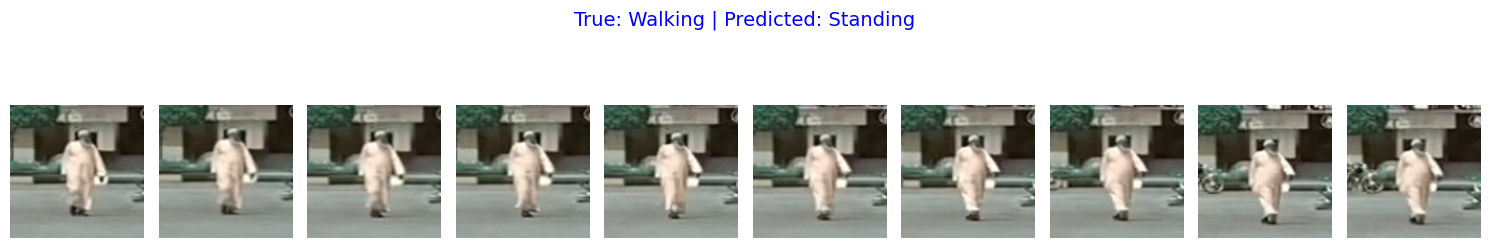

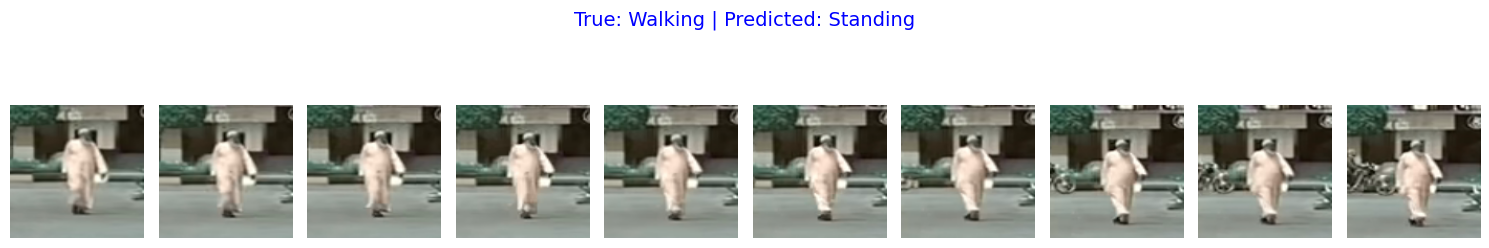

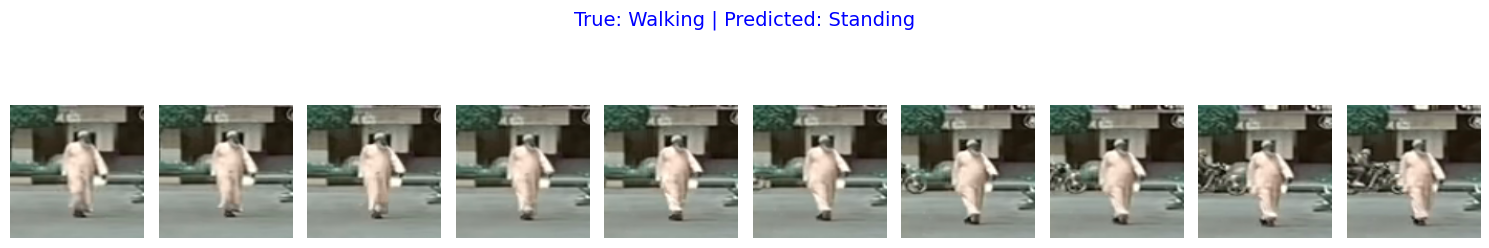

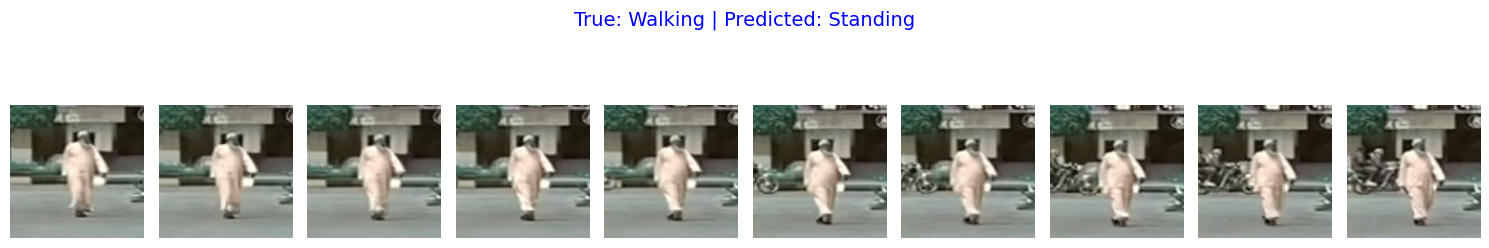

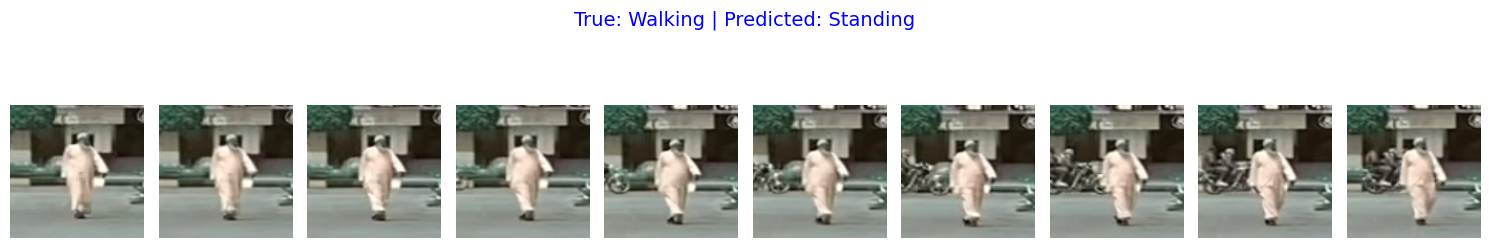

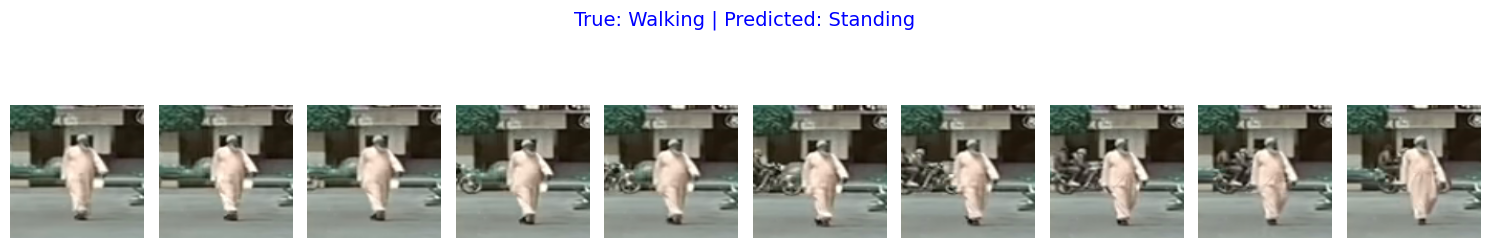

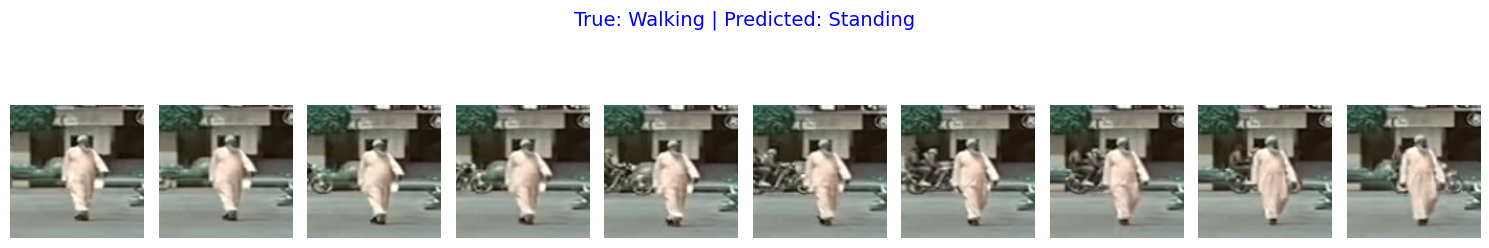

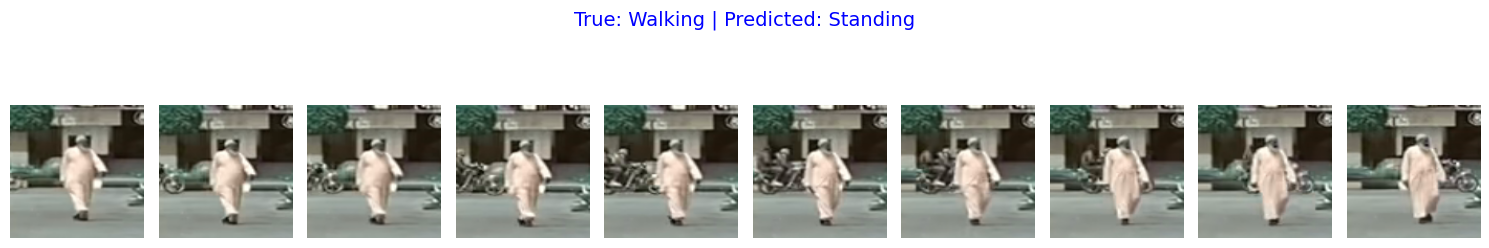

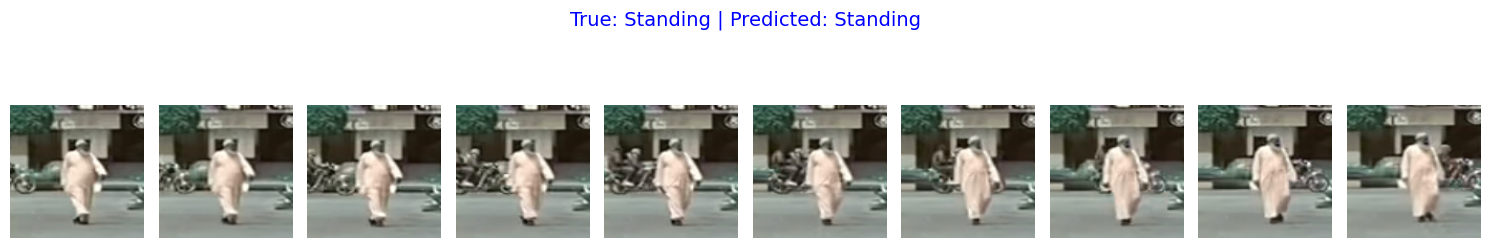

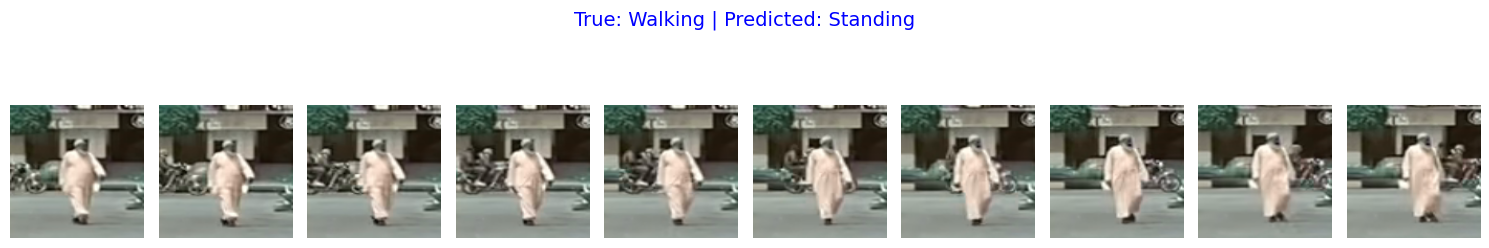

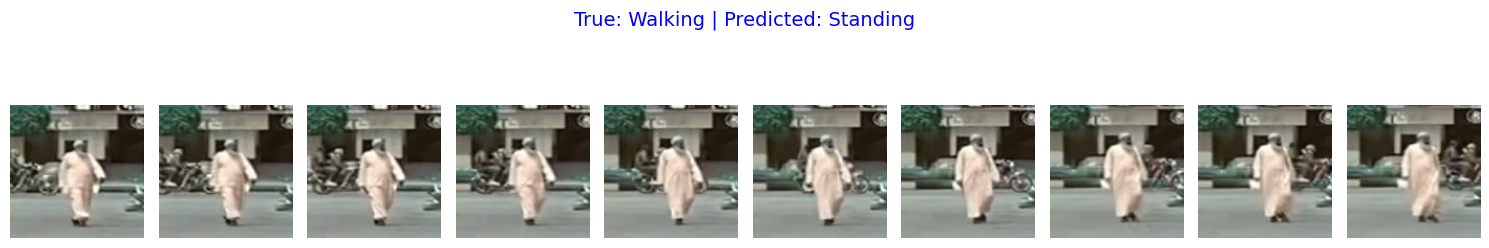

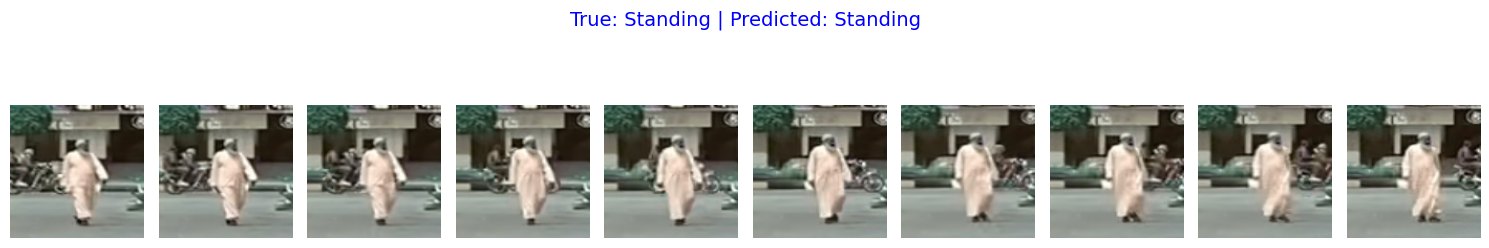

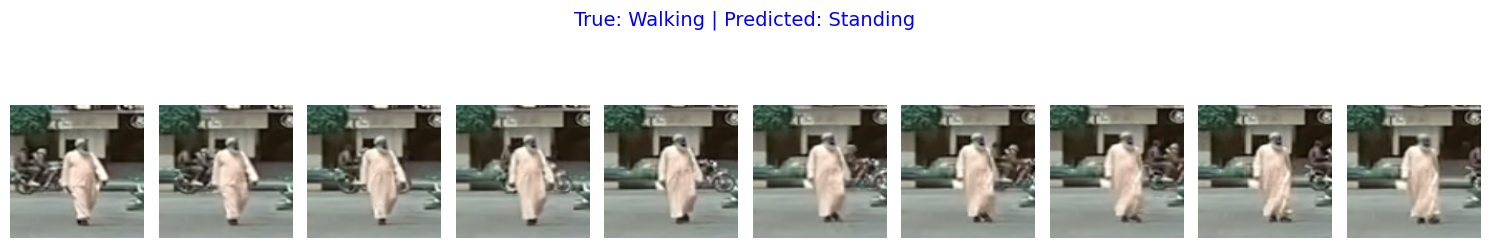

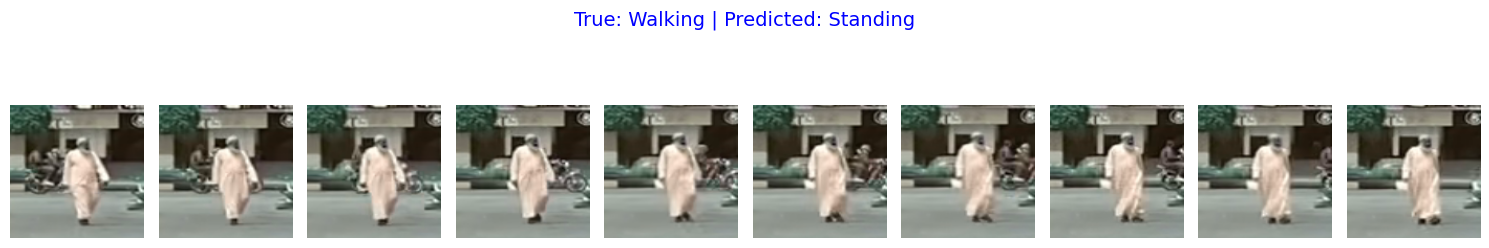

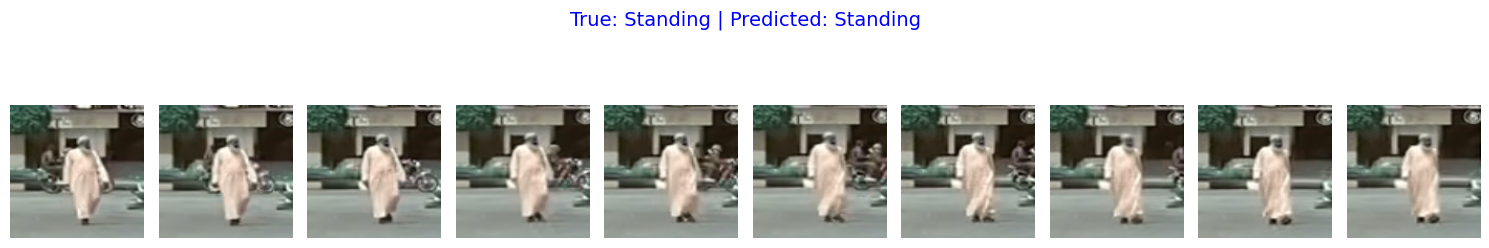

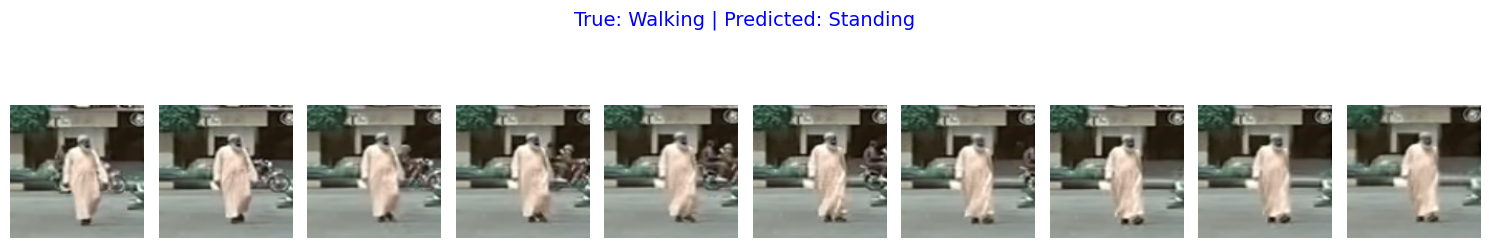

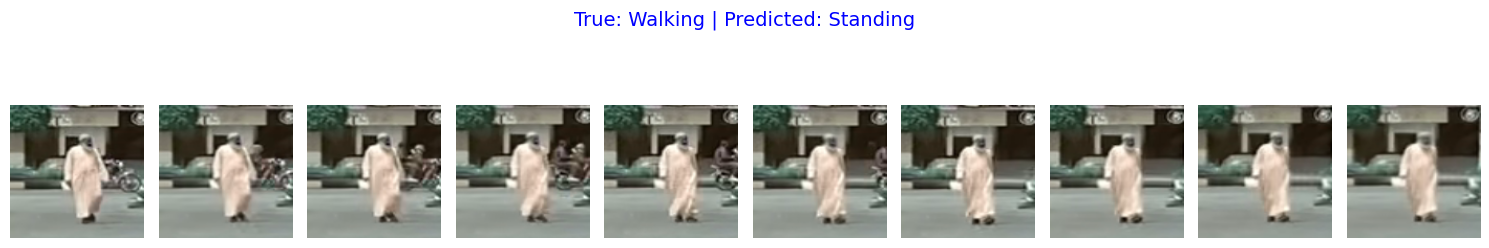

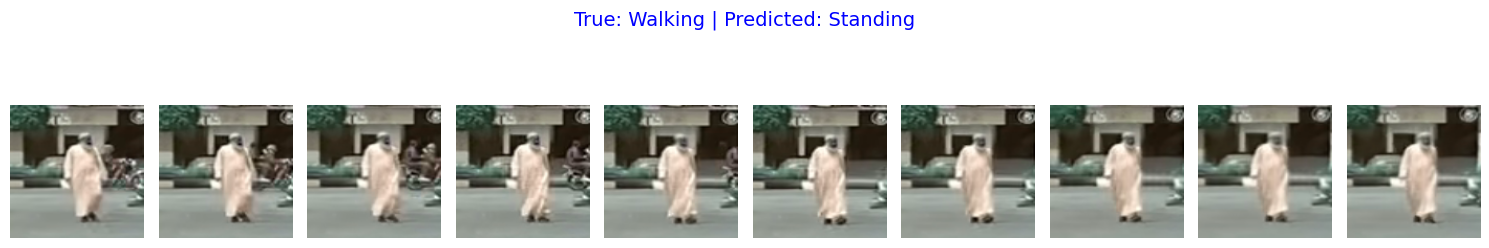

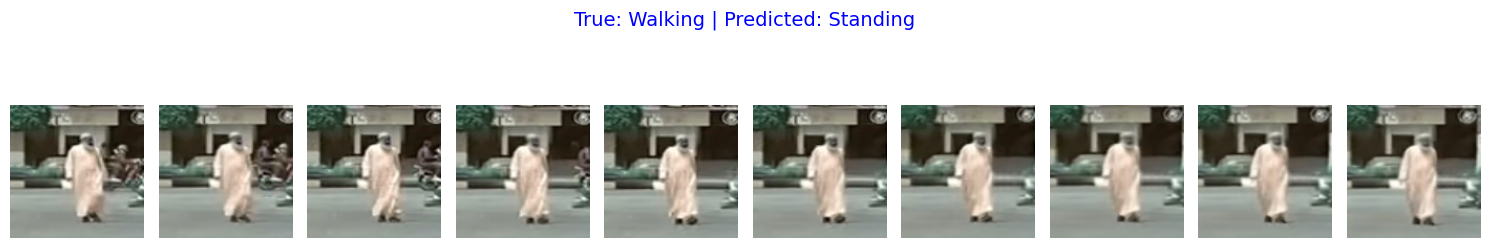

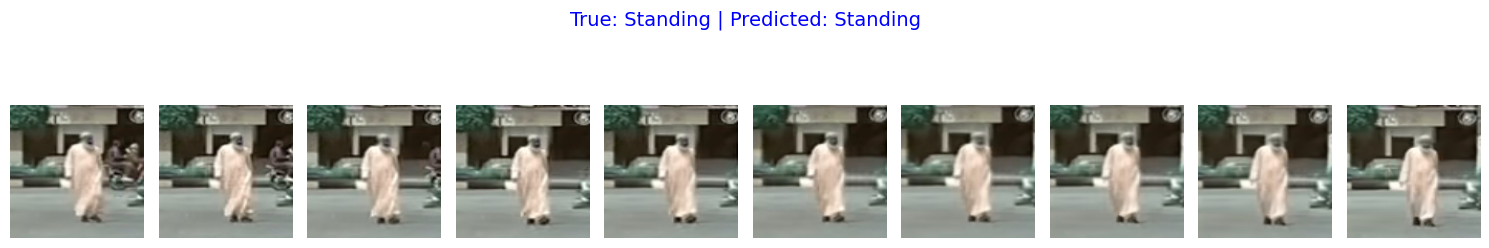

In [ ]:
# Ensure you are accessing correct dimensions from features and labels
num_samples = 20
for i in range(num_samples):
    fig, axes = plt.subplots(1, SEQUENCE_LENGTH, figsize=(15, 3))

    # Safely convert class index to label
    true_label = classes_list[int(labels_test[i][0])] if isinstance(labels_test[i], (np.ndarray, list)) else classes_list[int(labels_test[i])]
    predicted_label = classes_list[int(predicted_labels[i][0])] if isinstance(predicted_labels[i], (np.ndarray, list)) else classes_list[int(predicted_labels[i])]

    fig.suptitle(f"True: {true_label} | Predicted: {predicted_label}", fontsize=14, color='blue')

    # Ensure you don't exceed the SEQUENCE_LENGTH limit
    sequence_length = min(SEQUENCE_LENGTH, len(features[i]))  # Handle edge cases if sequence length is larger than the available frames

    for j in range(sequence_length):  # Loop through actual available frames
        frame = features[i][j]

        # Convert to uint8 if normalized
        if frame.max() <= 1.0:
            frame = (frame * 255).astype('uint8')
        else:
            frame = frame.astype('uint8')

        axes[j].imshow(frame)
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [89]:
%%capture
!pip install ultralytics==8.3.40

In [94]:
import cv2
import numpy as np
from collections import deque
from ultralytics import YOLO
from tensorflow.keras.models import load_model
import os

frames_pedestrians = []

# Load models
yolo_model = YOLO("/content/yolo11s.pt")
LRCN_model = load_model("/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/LRCN_model___Date_Time_2025_04_21__11_39_46___Loss_0.6259127855300903___Accuracy_0.7486910820007324.h5")

# Parameters
input_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/test.mov'
output_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/predicted_output.avi'

# Parameters
SEQUENCE_LENGTH = 20
IMAGE_SIZE = 128
CLASSES_LIST = ["walking", "standing", "crossing"]
PREDICTION_COLORS = {
    "walking": (0, 255, 0),
    "standing": (0, 0, 255),
    "crossing": (0, 0, 128),
}
ANIMAL_CLASS_IDS = list(range(15, 24))  # COCO: cat to elephant

# Paths
input_video_path = '/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/test.mov'
output_video_path = input_video_path.replace("test.mov", "predicted_output.mp4")
yolo_path = "/content/yolo11s.pt"
lrcn_path = "/content/drive/MyDrive/Master/Autonmous Cars/Work/Pedestrians Intention Detection /Version 3/LRCN_model___Date_Time_2025_04_21__11_39_46___Loss_0.6259127855300903___Accuracy_0.7486910820007324.h5"

# Load models
print("[INFO] Loading models...")
yolo_model = YOLO(yolo_path)
LRCN_model = load_model(lrcn_path)

# Initialize video
cap = cv2.VideoCapture(input_video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Sequence buffer
sequence = deque(maxlen=SEQUENCE_LENGTH)
frame_count = 0
processed_frames = 0

print("[INFO] Processing video...")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Skip every 5 frames
    if frame_count % 5 != 0:
        frame_count += 1
        continue

    processed_frames += 1
    frame_count += 1

    results = yolo_model(frame)[0]

    for detection in results.boxes.data:
        x1, y1, x2, y2, conf, cls = detection.cpu().numpy()
        class_id = int(cls)
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        if class_id == 0:  # Person
            cropped = frame[y1:y2, x1:x2]
            if cropped.size == 0:
                continue
            processed = cv2.resize(cropped, (IMAGE_SIZE, IMAGE_SIZE)) / 255.0
            sequence.append(processed)

            if len(sequence) == SEQUENCE_LENGTH:
                input_seq = np.array(sequence).reshape(1, SEQUENCE_LENGTH, IMAGE_SIZE, IMAGE_SIZE, 3)
                prediction = LRCN_model.predict(input_seq, verbose=0)
                predicted_class = np.argmax(prediction)
                predicted_label = CLASSES_LIST[predicted_class]
                color = PREDICTION_COLORS[predicted_label]

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, predicted_label, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        elif class_id in ANIMAL_CLASS_IDS:
            cv2.rectangle(frame, (x1, y1), (x2, y2), (128, 0, 128), 2)
            cv2.putText(frame, "Animal", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (128, 0, 128), 2)

    out.write(frame)
    frames_pedestrians.append(frame)

cap.release()
out.release()
print(f"[DONE] Processed {processed_frames} frames out of {frame_count}.")
print(f"[INFO] Prediction video saved to: {output_video_path}")


[INFO] Loading models...


[INFO] Processing video...

0: 320x640 4 persons, 14 cars, 262.0ms
Speed: 14.7ms preprocess, 262.0ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 4 persons, 12 cars, 1 umbrella, 263.8ms
Speed: 4.3ms preprocess, 263.8ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 3 persons, 14 cars, 1 motorcycle, 1 umbrella, 241.5ms
Speed: 5.3ms preprocess, 241.5ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 5 persons, 2 bicycles, 15 cars, 1 umbrella, 249.4ms
Speed: 3.9ms preprocess, 249.4ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 6 persons, 10 cars, 1 motorcycle, 1 truck, 1 umbrella, 239.7ms
Speed: 5.3ms preprocess, 239.7ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 5 persons, 1 bicycle, 10 cars, 2 umbrellas, 412.8ms
Speed: 5.5ms preprocess, 412.8ms inference, 2.7ms postprocess per image at shape (1, 3, 320, 640)

0: 320x640 5 persons, 

In [96]:
# from IPython.display import HTML, Video, Image, clear_output
# from matplotlib import animation, rc
# import numpy as np
# import matplotlib.pyplot as plt
# rc('animation', html='jshtml')

# # Define create_animation function
# def create_animation(ims):
#     fig = plt.figure(figsize=(10, 6))
#     im = plt.imshow(cv2.cvtColor(ims[0], cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.close()

#     def animate_func(i):
#         im.set_array(cv2.cvtColor(ims[i], cv2.COLOR_BGR2RGB))
#         return [im]

#     return animation.FuncAnimation(fig, animate_func, frames=len(ims), interval=1000 // 3)

# # Call the create_animation function with processed_frames
# animation_obj = create_animation(np.array(frames_pedestrians))

# # Display the animation
# HTML(animation_obj.to_jshtml())

### Model conclusion

In [97]:
import collections
print(collections.Counter(labels))  # where labels is your class ID list

Counter({np.int64(1): 1532, np.int64(0): 928, np.int64(2): 914})


In [98]:
prediction = LRCN_model.predict(input_seq, verbose=0)
print("Raw prediction:", prediction)


Raw prediction: [[   0.076068     0.92014   0.0037916]]
